In [2]:
from importlib.metadata import Distribution
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL.ImageColor import colormap
from pandas.conftest import index
from pandas.core.interchange.dataframe_protocol import DataFrame
from pandas.io.sas.sas_constants import dataset_length, column_data_length_offset
from prometheus_client import Histogram
from scipy.ndimage import maximum

data = pd.read_csv("student_study_habits_cgpa_1000.csv")
data.info()
data.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Student_ID                             1000 non-null   object 
 1   Study_Hours                            1000 non-null   int64  
 2   Sleep_Hours                            1000 non-null   int64  
 3   Age (Years)                            894 non-null    float64
 4   Attendance_Rate                        1000 non-null   int64  
 5   Gender                                 965 non-null    object 
 6   Current Semester                       950 non-null    float64
 7   Do you have meritorious scholarship ?  950 non-null    object 
 8   Social_Media_Hours                     1000 non-null   int64  
 9   CGPA                                   1000 non-null   float64
dtypes: float64(3), int64(4), object(3)
memory usage: 78.3+ KB


,Student_ID,Study_Hours,Sleep_Hours,Age (Years),Attendance_Rate,Gender,Current Semester,Do you have meritorious scholarship ?,Social_Media_Hours,CGPA
0,S999,7,5,22.0,85,Female,4.0,Yes,1,3.29
1,S1000,4,6,22.0,67,Male,4.0,No,1,3.16
2,S1001,5,4,20.0,95,Male,4.0,Yes,5,3.55
3,S1002,7,8,21.0,89,Male,4.0,Yes,5,3.06
4,S1003,3,8,21.0,82,Female,4.0,Yes,4,2.90
5,S1004,5,7,21.0,73,Male,4.0,Yes,2,3.04
6,S1005,5,5,20.0,73,Female,4.0,No,4,3.10
7,S1006,7,4,21.0,61,Male,4.0,Yes,3,3.21
8,S1007,2,5,20.0,96,Female,4.0,No,4,2.75
9,S1008,3,4,20.0,64,Male,2.0,Yes,0,3.10


Distribution of dataset

In [3]:
data_cleaning = data.dropna()
data_cleaning

,Student_ID,Study_Hours,Sleep_Hours,Age (Years),Attendance_Rate,Gender,Current Semester,Do you have meritorious scholarship ?,Social_Media_Hours,CGPA
0,S999,7,5,22.0,85,Female,4.0,Yes,1,3.29
1,S1000,4,6,22.0,67,Male,4.0,No,1,3.16
2,S1001,5,4,20.0,95,Male,4.0,Yes,5,3.55
3,S1002,7,8,21.0,89,Male,4.0,Yes,5,3.06
4,S1003,3,8,21.0,82,Female,4.0,Yes,4,2.90
...,...,...,...,...,...,...,...,...,...,...
889,S1888,2,7,20.0,65,Female,8.0,No,3,2.60
890,S1889,3,4,23.0,65,Male,8.0,Yes,2,3.09
891,S1890,5,5,22.0,93,Male,9.0,No,4,3.24
892,S1891,5,5,25.0,60,Female,11.0,No,3,2.57


In [4]:
Male_count = (data_cleaning['Gender'] == 'Male').sum()
Female_count = (data_cleaning['Gender'] == 'Female').sum()

print("Male:", Male_count)
print("Female:", Female_count)


Male: 480
Female: 414


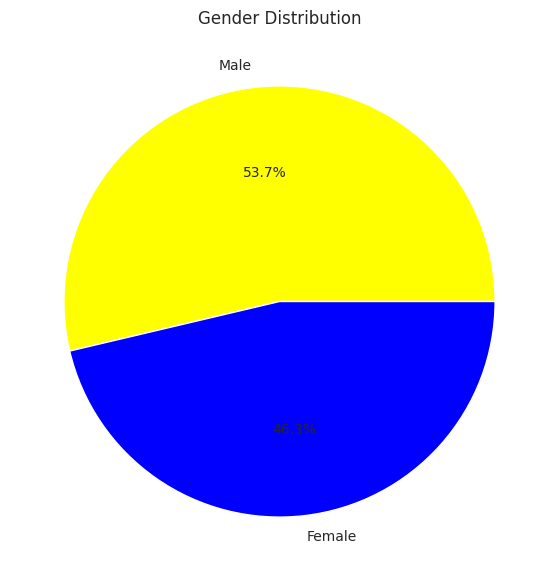

In [5]:
counts = [Male_count, Female_count]
labels = ['Male', 'Female']
plt.figure(figsize=(7,7))
plt.pie(counts, labels=labels, autopct='%1.1f%%',colors=['yellow', 'blue'])
plt.title("Gender Distribution")
plt.show()

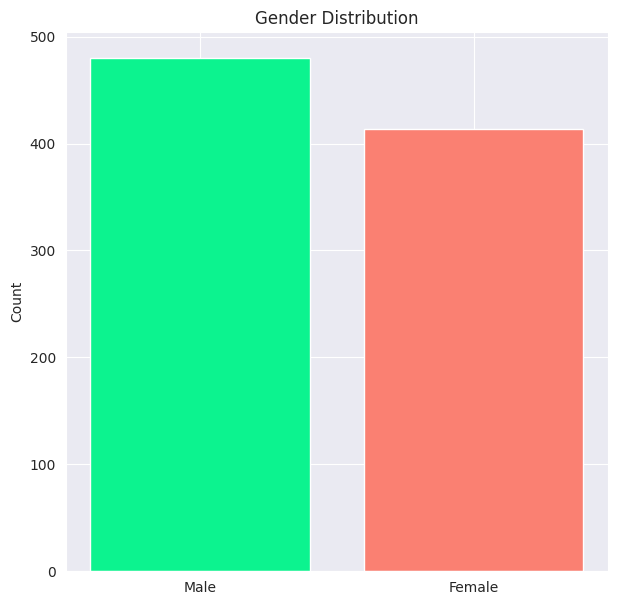

In [27]:
counts = [Male_count, Female_count]
labels = ['Male', 'Female']

plt.figure(figsize=(7,7))
plt.bar(labels, counts, color=['#0cf38f', 'salmon'])
plt.title("Gender Distribution")
plt.ylabel("Count")
plt.show()

In [6]:
data.describe(include='all')


,Student_ID,Study_Hours,Sleep_Hours,Age (Years),Attendance_Rate,Gender,Current Semester,Do you have meritorious scholarship ?,Social_Media_Hours,CGPA
count,1000,1000.0000,1000.000000,894.000000,1000.000000,965,950.000000,950,1000.000000,1000.000000
unique,1000,NaN,NaN,NaN,NaN,2,NaN,2,NaN,NaN
top,S1998,NaN,NaN,NaN,NaN,Male,NaN,No,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,516,NaN,578,NaN,NaN
mean,NaN,3.9600,5.980000,21.354586,79.700000,NaN,6.558947,NaN,2.524000,3.068660
std,NaN,2.0036,1.416194,1.603676,11.785368,NaN,3.358176,NaN,1.709487,0.352994
min,NaN,1.0000,4.000000,18.000000,60.000000,NaN,1.000000,NaN,0.000000,1.910000
25%,NaN,2.0000,5.000000,20.000000,69.000000,NaN,3.000000,NaN,1.000000,2.830000
50%,NaN,4.0000,6.000000,21.000000,80.000000,NaN,7.000000,NaN,3.000000,3.080000
75%,NaN,6.0000,7.000000,22.000000,90.000000,NaN,10.000000,NaN,4.000000,3.320000


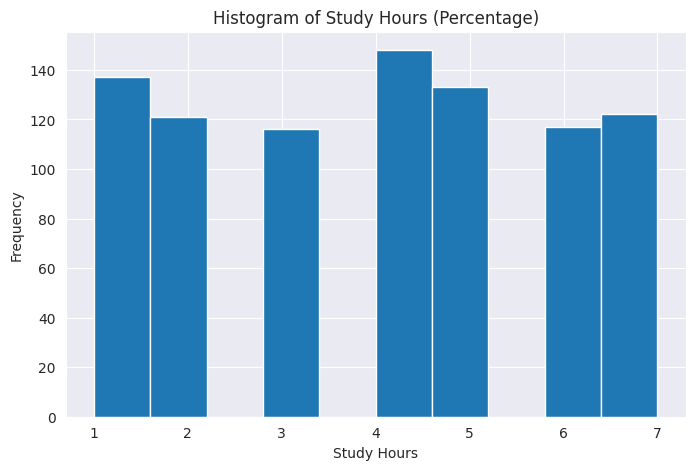

In [7]:

plt.figure(figsize=(8,5))

plt.hist(
    data_cleaning['Study_Hours'],bins=10, )

plt.title("Histogram of Study Hours (Percentage)")
plt.xlabel("Study Hours")
plt.ylabel("Frequency")

plt.show()

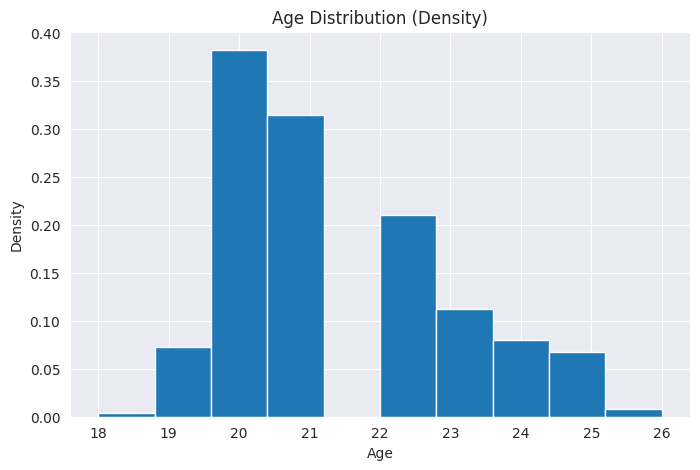

In [8]:
plt.figure(figsize=(8,5))
plt.hist(data_cleaning['Age (Years)'].dropna(), bins=10, density=True)
plt.title("Age Distribution (Density)")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

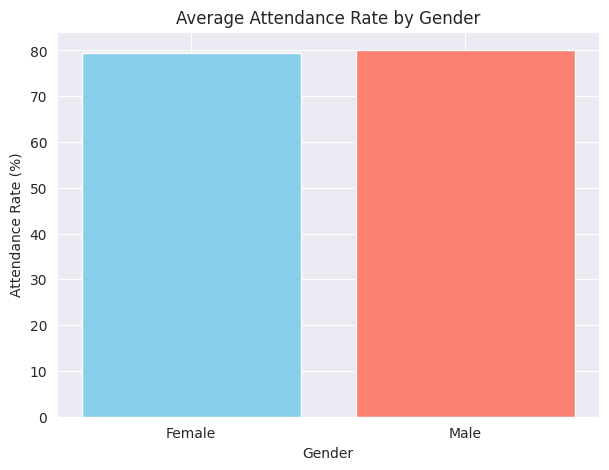

In [9]:
gender_attendance = data_cleaning.groupby("Gender")["Attendance_Rate"].mean()

plt.figure(figsize=(7,5))
plt.bar(gender_attendance.index, gender_attendance.values,
        color=["skyblue", "salmon"])   # two different colors
plt.title("Average Attendance Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Attendance Rate (%)")
plt.show()

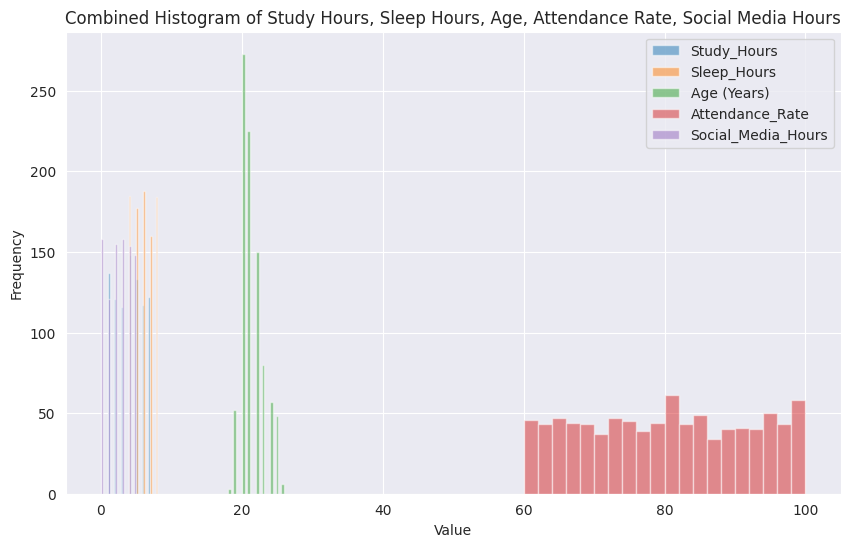

In [10]:
numeric_cols = [
    "Study_Hours",
    "Sleep_Hours",
    "Age (Years)",
    "Attendance_Rate",
    "Social_Media_Hours"
]

plt.figure(figsize=(10,6))

for col in numeric_cols:
    plt.hist(data_cleaning[col].dropna(), bins=20, alpha=0.5, label=col)

plt.title("Combined Histogram of Study Hours, Sleep Hours, Age, Attendance Rate, Social Media Hours")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()



data['CGPA'].max()

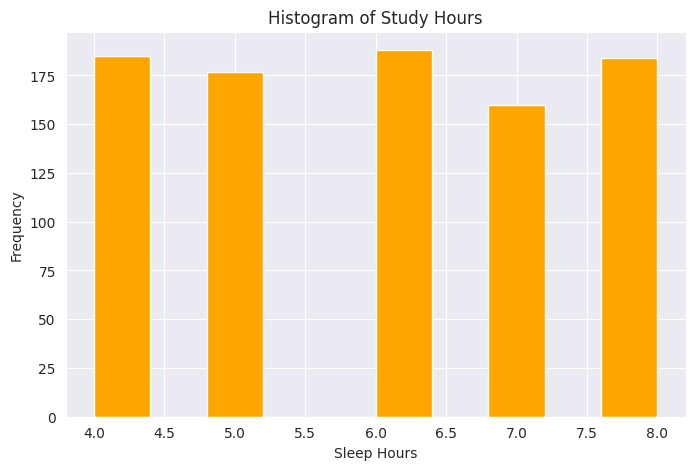

In [11]:
plt.figure(figsize=(8,5))
plt.hist(data_cleaning['Sleep_Hours'],bins=10, color='orange' )
plt.title("Histogram of Study Hours")
plt.xlabel("Sleep Hours")
plt.ylabel("Frequency")

plt.show()

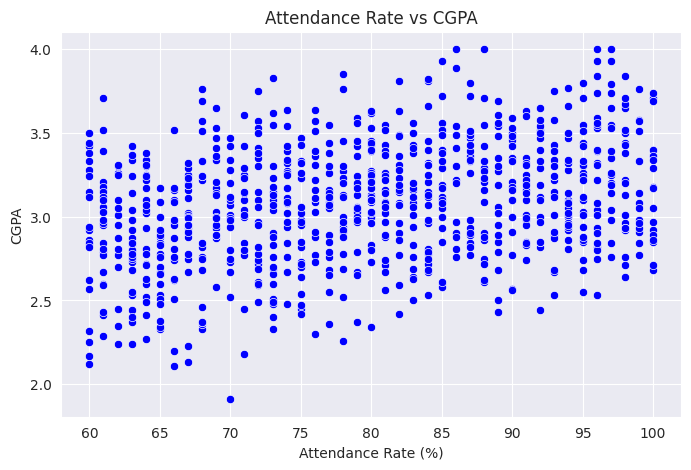

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=data_cleaning, x="Attendance_Rate", y="CGPA", color='blue')
plt.title("Attendance Rate vs CGPA")
plt.xlabel("Attendance Rate (%)")
plt.ylabel("CGPA")
plt.show()

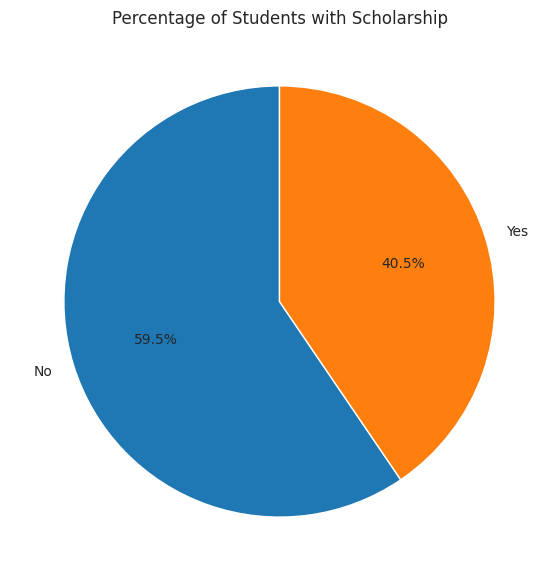

In [13]:
counts = data_cleaning['Do you have meritorious scholarship ?'].value_counts()
labels = counts.index

plt.figure(figsize=(7,7))
plt.pie(counts, labels=labels, autopct="%0.1f%%", startangle=90)
plt.title("Percentage of Students with Scholarship")
plt.show()



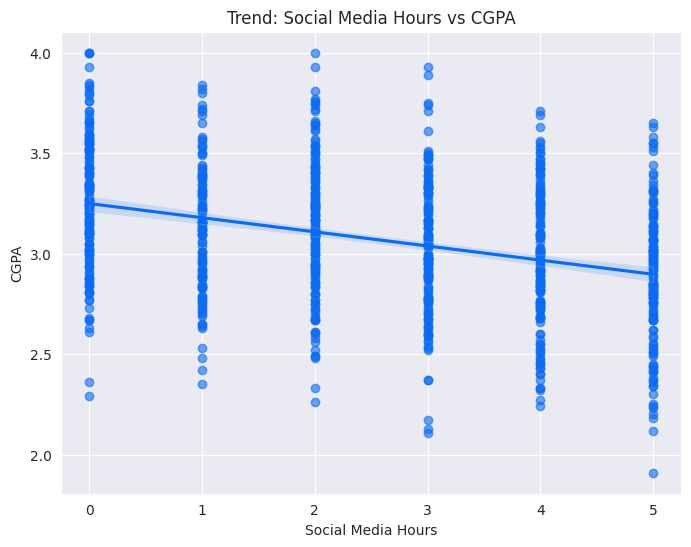

In [14]:
plt.figure(figsize=(8,6))
sns.regplot(x=data_cleaning['Social_Media_Hours'], y=data_cleaning['CGPA'], scatter_kws={'alpha':0.6}, color='#0a6bf5')
plt.title("Trend: Social Media Hours vs CGPA")
plt.xlabel("Social Media Hours")
plt.ylabel("CGPA")
plt.show()


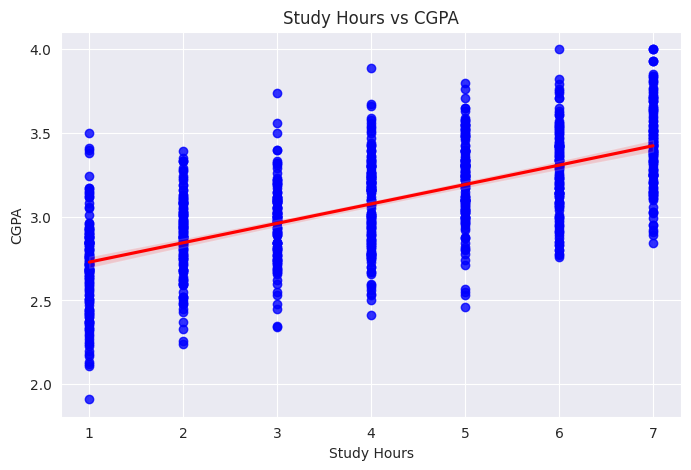

In [15]:
plt.figure(figsize=(8,5))
sns.regplot(x='Study_Hours', y='CGPA', data=data_cleaning, scatter_kws={'color':'blue'}, line_kws={'color':'red'})
plt.title("Study Hours vs CGPA")
plt.xlabel("Study Hours")
plt.ylabel("CGPA")
plt.show()

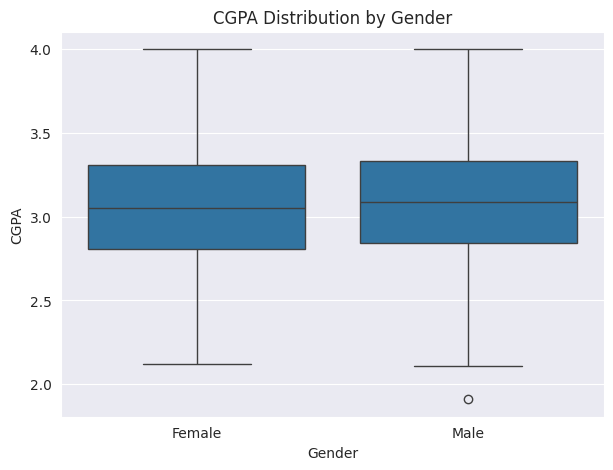

In [16]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Gender', y='CGPA', data=data)
plt.title("CGPA Distribution by Gender")
plt.show()

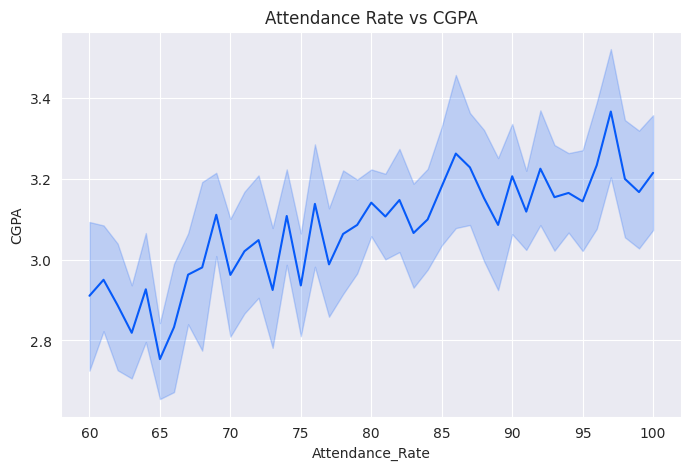

In [17]:
plt.figure(figsize=(8,5))
sns.lineplot(x='Attendance_Rate', y='CGPA', data=data_cleaning, color='#065af9')
plt.title("Attendance Rate vs CGPA")
plt.show()

In [18]:
Q1 = data_cleaning['CGPA'].quantile(0.25)
Q3 = data_cleaning['CGPA'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print( "Range ",lower_bound ,"-" ,upper_bound)

outliers = data_cleaning[(data_cleaning['CGPA'] < lower_bound) | (data_cleaning['CGPA'] > upper_bound)]
outliers


Range  2.135 - 4.015000000000001


,Student_ID,Study_Hours,Sleep_Hours,Age (Years),Attendance_Rate,Gender,Current Semester,Do you have meritorious scholarship ?,Social_Media_Hours,CGPA
111,S1110,1,6,23.0,60,Female,3.0,Yes,5,2.12
154,S1153,1,8,22.0,66,Male,2.0,Yes,3,2.11
554,S1553,1,5,20.0,70,Male,10.0,Yes,5,1.91
691,S1690,1,7,21.0,67,Female,3.0,No,3,2.13


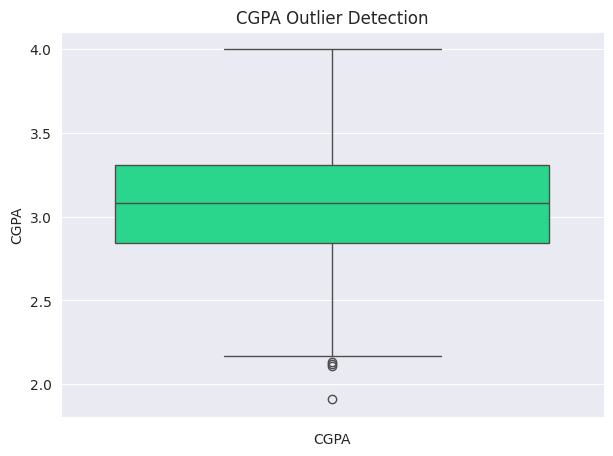

In [19]:
plt.figure(figsize=(7,5))
sns.boxplot(data_cleaning['CGPA'], color='#0cf38f')
plt.title("CGPA Outlier Detection")
plt.xlabel("CGPA")
plt.show()


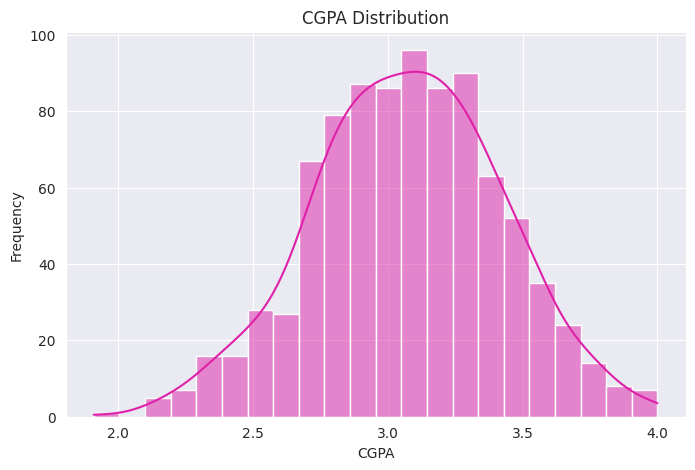

The mean of CGPA:  3.07


In [20]:
plt.figure(figsize=(8,5))
sns.histplot(data_cleaning['CGPA'], kde=True, color='#df20a8')
plt.title("CGPA Distribution")
plt.xlabel("CGPA")
plt.ylabel("Frequency")
plt.show()
mean_cgpa = data_cleaning['CGPA'].mean()
print("The mean of CGPA: ",round(mean_cgpa, 2))

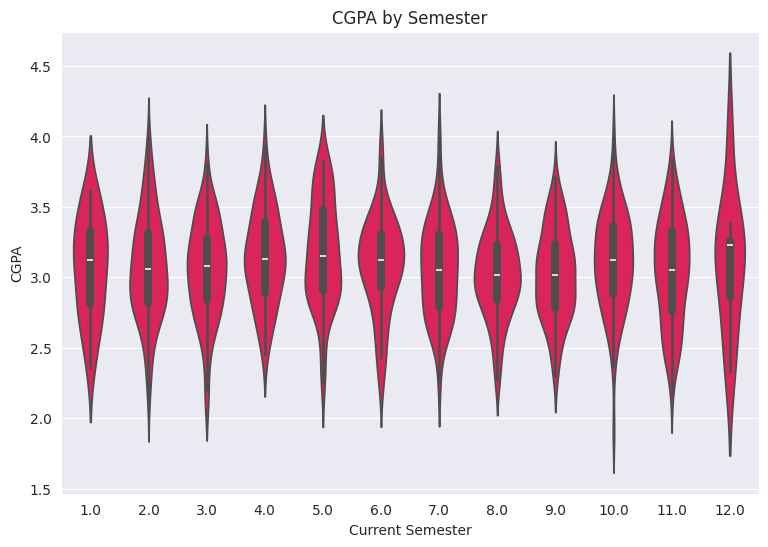

In [21]:
plt.figure(figsize=(9,6))
sns.violinplot(x='Current Semester', y='CGPA', data=data,color='#f8074f')
plt.title("CGPA by Semester")
plt.show()

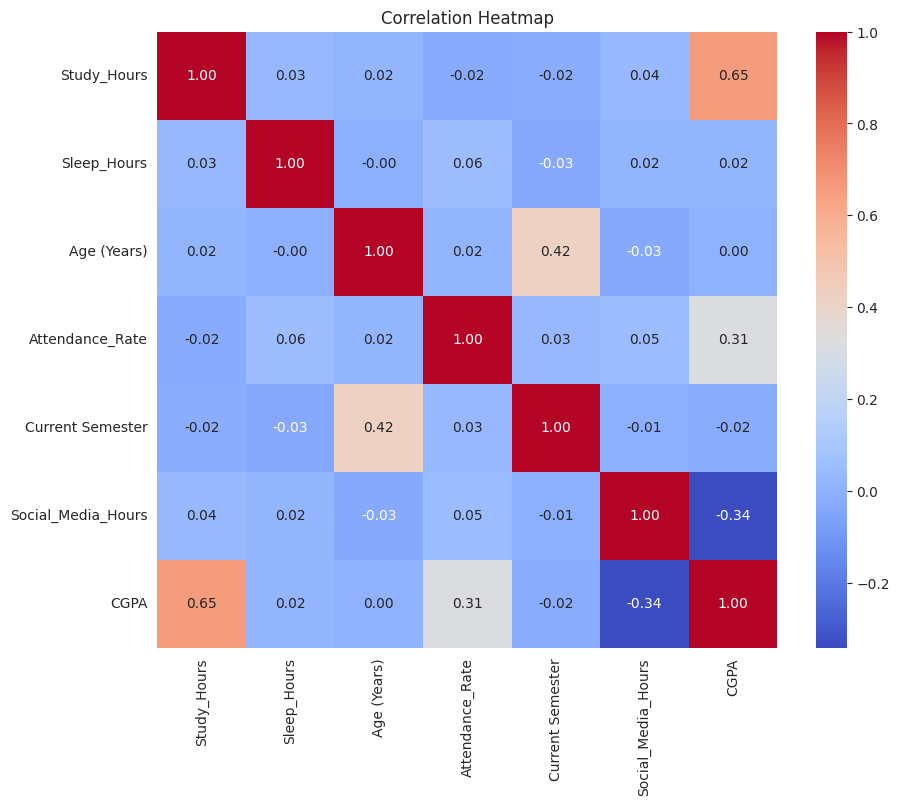

In [22]:
corr = data_cleaning.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
